In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer #It fills the missing value and calculates mean value of the missing values
from sklearn.pipeline import Pipeline

In [48]:
df = pd.read_csv('50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [49]:
num_cols = df.select_dtypes('number').columns
print(num_cols.tolist())   #num_cols = numerical columns

['R&D Spend', 'Administration', 'Marketing Spend', 'Profit']


In [50]:
cat_cols = df.select_dtypes(exclude = 'number').columns
print(cat_cols.tolist())   #cat_cols = categorical columns

['State']


In [51]:
# initializing imputers for numerical and categorical columns

num_imp=SimpleImputer()# by default mean strategy is used ...likhna na likhna 
cal_imp=SimpleImputer(strategy='most_frequent')

In [52]:
df[num_cols]=num_imp.fit_transform(df[num_cols])
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [53]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [54]:
df[cat_cols]=cal_imp.fit_transform(df[cat_cols])
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [55]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [56]:
cat_cols = ['State']
cat_enc = OneHotEncoder(drop = 'first')
dummy_cols = cat_enc.fit_transform(df[cat_cols]).toarray()
dummy_df = pd.DataFrame(dummy_cols)

In [57]:
df['State'].value_counts()

State
New York      17
California    17
Florida       16
Name: count, dtype: int64

In [58]:
dummy_df

,0,1
0,0.0,1.0
1,0.0,0.0
2,1.0,0.0
3,0.0,1.0
4,1.0,0.0
5,0.0,1.0
6,0.0,0.0
7,1.0,0.0
8,0.0,1.0
9,0.0,0.0


In [59]:
clean_df = pd.concat([df, dummy_df], 
                      axis=1).drop(columns = cat_cols +['State'])

In [60]:
clean_df

,R&D Spend,Administration,Marketing Spend,Profit,0,1
0,165349.20,136897.80,471784.10,192261.83,0.0,1.0
1,162597.70,151377.59,443898.53,191792.06,0.0,0.0
2,153441.51,101145.55,407934.54,191050.39,1.0,0.0
3,144372.41,118671.85,383199.62,182901.99,0.0,1.0
4,142107.34,91391.77,366168.42,166187.94,1.0,0.0
5,131876.90,99814.71,362861.36,156991.12,0.0,1.0
6,134615.46,147198.87,127716.82,156122.51,0.0,0.0
7,130298.13,145530.06,323876.68,155752.60,1.0,0.0
8,120542.52,148718.95,311613.29,152211.77,0.0,1.0
9,123334.88,108679.17,304981.62,149759.96,0.0,0.0


In [61]:
scaler = StandardScaler()
clean_df[num_cols] = scaler.fit_transform(clean_df[num_cols])
clean_df

,R&D Spend,Administration,Marketing Spend,Profit,0,1
0,2.016411,0.560753,2.153943,2.011203,0.0,1.0
1,1.955860,1.082807,1.923600,1.999430,0.0,0.0
2,1.754364,-0.728257,1.626528,1.980842,1.0,0.0
3,1.554784,-0.096365,1.422210,1.776627,0.0,1.0
4,1.504937,-1.079919,1.281528,1.357740,1.0,0.0
5,1.279800,-0.776239,1.254210,1.127250,0.0,1.0
6,1.340066,0.932147,-0.688150,1.105481,0.0,0.0
7,1.245057,0.871980,0.932186,1.096210,1.0,0.0
8,1.030369,0.986952,0.830887,1.007470,0.0,1.0
9,1.091819,-0.456640,0.776107,0.946022,0.0,0.0


In [62]:
X = clean_df.drop('Profit', axis=1).values
print(X)

[[ 2.01641149e+00  5.60752915e-01  2.15394309e+00  0.00000000e+00
   1.00000000e+00]
 [ 1.95586034e+00  1.08280658e+00  1.92360040e+00  0.00000000e+00
   0.00000000e+00]
 [ 1.75436374e+00 -7.28257028e-01  1.62652767e+00  1.00000000e+00
   0.00000000e+00]
 [ 1.55478369e+00 -9.63646307e-02  1.42221024e+00  0.00000000e+00
   1.00000000e+00]
 [ 1.50493720e+00 -1.07991935e+00  1.28152771e+00  1.00000000e+00
   0.00000000e+00]
 [ 1.27980001e+00 -7.76239071e-01  1.25421046e+00  0.00000000e+00
   1.00000000e+00]
 [ 1.34006641e+00  9.32147208e-01 -6.88149930e-01  0.00000000e+00
   0.00000000e+00]
 [ 1.24505666e+00  8.71980011e-01  9.32185978e-01  1.00000000e+00
   0.00000000e+00]
 [ 1.03036886e+00  9.86952101e-01  8.30886909e-01  0.00000000e+00
   1.00000000e+00]
 [ 1.09181921e+00 -4.56640246e-01  7.76107440e-01  0.00000000e+00
   0.00000000e+00]
 [ 6.20398248e-01 -3.87599089e-01  1.49807267e-01  1.00000000e+00
   0.00000000e+00]
 [ 5.93085418e-01 -1.06553960e+00  3.19833623e-01  0.00000000e+00

In [63]:
y = clean_df['Profit'].values
print(y)

[ 2.01120333  1.99942997  1.98084225  1.77662724  1.35774012  1.12724963
  1.10548055  1.09620987  1.00746967  0.94602247  0.85484675  0.80816756
  0.74115484  0.55874952  0.51602637  0.44871967  0.3754357   0.33477114
  0.307116    0.26977265  0.16193522 -0.01753384 -0.04161264 -0.08216943
 -0.08672946 -0.11549309 -0.15736664 -0.17554233 -0.21879755 -0.27588222
 -0.3026246  -0.36412744 -0.36552389 -0.38178711 -0.38344421 -0.38929092
 -0.53393161 -0.5529549  -0.77149734 -0.77709368 -0.84641135 -0.85746568
 -1.01536466 -1.05896021 -1.17320899 -1.18008224 -1.56692212 -1.74062718
 -1.91321197 -2.43931323]


In [64]:
from sklearn.model_selection import train_test_split 

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) 

In [66]:
from sklearn.linear_model import LinearRegression


regressor = LinearRegression()
regressor.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [67]:
y_pred = regressor.predict(X_test)
print(y_pred)

[ 0.35964537 -0.68680305 -0.30914311 -1.64544854  0.41948345 -1.53129232
 -0.05692299 -0.28493955 -0.36122738  0.02718688]


ValueError: x and y must be the same size

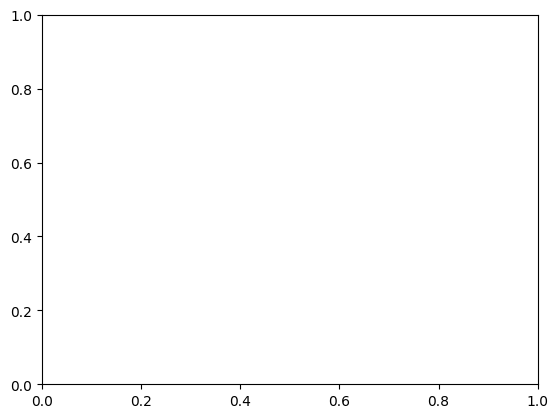

In [ ]:
plt.scatter(X_train[:,0], y_train, color='red')
plt.xlabel('R&D Spend')
plt.ylabel('Profit')
plt.title('R&D Spend vs Profit')
plt.show()